# 12. Final Summary

## Objective Of Final Summary

This notebook closes the EDA project by consolidating the most important analytical findings, documenting the project journey, and translating the work into modeling and business recommendations.

It is intended to act as a portfolio-ready handoff notebook rather than a new analysis notebook.


In [11]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import RANDOM_STATE, TARGET_COLUMN, TEST_SIZE

raw_data_path = project_root / "data" / "raw" / "telco.csv"
cleaned_data_path = project_root / "data" / "interim" / "telco_churn_cleaned.csv"
engineered_data_path = project_root / "data" / "processed" / "telco_churn_engineered.csv"
feature_selection_notebook_path = project_root / "notebooks" / "10_feature_selection.ipynb"

raw_df = pd.read_csv(raw_data_path)
cleaned_df = pd.read_csv(cleaned_data_path) if cleaned_data_path.exists() else None
df = pd.read_csv(engineered_data_path)

target_rate = round(df["Churn_bin"].mean() * 100, 2)
target_counts = df["Churn"].value_counts().to_dict()
missing_total = int(df.isna().sum().sum())
duplicate_total = int(df.duplicated().sum())
raw_totalcharges_blank = int(raw_df["TotalCharges"].astype(str).str.strip().eq("").sum())
raw_totalcharges_tenure_zero = int(raw_df.loc[raw_df["TotalCharges"].astype(str).str.strip().eq(""), "tenure"].eq(0).sum())

feature_columns = [column for column in df.columns if column not in ["customerID", "Churn", "Churn_bin"]]
numeric_features = df[feature_columns].select_dtypes(include=["number", "bool"]).columns.tolist()
binary_features = [
    column for column in numeric_features
    if set(pd.Series(df[column]).dropna().astype(float).unique()).issubset({0.0, 1.0})
]
continuous_features = [column for column in numeric_features if column not in binary_features]

engineered_feature_markers = ("_bin", "_ordinal", "_group", "_profile", "_log", "_band", "_x_", "is_")
engineered_features = [column for column in feature_columns if any(marker in column for marker in engineered_feature_markers)]

combined_risk_profiles = (
    df.groupby(["Contract", "payment_method_group", "has_support_services"], dropna=False)["Churn_bin"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "churn_rate", "count": "segment_count"})
)
combined_risk_profiles = combined_risk_profiles.loc[combined_risk_profiles["segment_count"] >= 50].copy()
combined_risk_profiles["churn_rate_pct"] = (combined_risk_profiles["churn_rate"] * 100).round(2)
combined_risk_profiles = combined_risk_profiles.sort_values(["churn_rate", "segment_count"], ascending=[False, False])

manager_view_df = (
    df.groupby(["Contract", "tenure_band", "has_support_services"], dropna=False)["Churn_bin"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "churn_rate", "count": "segment_count"})
)
manager_view_df = manager_view_df.loc[manager_view_df["segment_count"] >= 40].copy()
manager_view_df["churn_rate_pct"] = (manager_view_df["churn_rate"] * 100).round(2)
manager_view_df = manager_view_df.sort_values(["churn_rate", "segment_count"], ascending=[False, False])

top_risk_segment = combined_risk_profiles.iloc[0]
low_risk_segment = combined_risk_profiles.loc[
    (combined_risk_profiles["Contract"] == "Two year")
    & (combined_risk_profiles["payment_method_group"] == "auto_payment")
    & (combined_risk_profiles["has_support_services"] == 0)
].iloc[0]
new_customer_risk = manager_view_df.loc[
    (manager_view_df["Contract"] == "Month-to-month")
    & (manager_view_df["tenure_band"] == "new")
    & (manager_view_df["has_support_services"] == 0)
].iloc[0]

feature_selection_snapshot = {
    "kept_feature_count": None,
    "review_feature_count": None,
    "dropped_feature_count": None,
    "top_keep_features": [],
}

if feature_selection_notebook_path.exists():
    notebook_json = json.loads(feature_selection_notebook_path.read_text())
    for cell in notebook_json.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source_text = "".join(cell.get("source", []))
        if "final_selection_summary" not in source_text:
            continue
        for output in cell.get("outputs", []):
            output_text = ""
            if "text" in output:
                output_text = "".join(output["text"])
            elif "data" in output and "text/plain" in output["data"]:
                output_text = "".join(output["data"]["text/plain"])
            if "kept_feature_count" in output_text and "top_keep_features" in output_text:
                feature_selection_snapshot.update(json.loads(output_text.replace("'", '"').replace("None", "null")))
                break

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)


## Project Goal

The project goal was to study customer churn in the IBM Telco dataset, understand the main drivers of churn, and prepare the dataset for reliable predictive modeling. The target variable is `Churn` (`Yes` / `No`), and the business value of the work is to help a telecom provider reduce customer loss by identifying which customer segments are most at risk and why.


## Project Recap

The analysis followed a structured EDA pipeline rather than isolated charting. Raw data was loaded and validated, cleaning rules were applied, univariate and target-based bivariate patterns were reviewed, multivariate redundancy was checked, engineered features were added, outliers were assessed, and feature selection was completed to prepare a modeling-ready dataset.


In [12]:
project_recap_df = pd.DataFrame(
    {
        "stage": [
            "Raw data loading",
            "Validation",
            "Cleaning",
            "Exploratory analysis",
            "Feature engineering",
            "Outlier review",
            "Feature selection",
        ],
        "status": [
            "Completed",
            "Completed",
            "Completed",
            "Completed",
            "Completed",
            "Completed",
            "Completed",
        ],
        "summary": [
            f"Loaded {raw_df.shape[0]} rows from the raw Telco churn dataset.",
            "Performed checks for blanks, duplicates, and schema consistency.",
            "Resolved TotalCharges blanks and stabilized data types for analysis.",
            "Completed univariate, bivariate, and multivariate churn-focused review.",
            f"Created {len(engineered_features)} engineered features to enrich churn signal.",
            "Reviewed outliers and kept business-valid edge cases rather than capping blindly.",
            f"Reduced the final feature space into keep, review, and drop groups for modeling.",
        ],
    }
)

project_recap_df


,stage,status,summary
0,Raw data loading,Completed,Loaded 7043 rows from the raw Telco churn dataset.
1,Validation,Completed,"Performed checks for blanks, duplicates, and schema consistency."
2,Cleaning,Completed,Resolved TotalCharges blanks and stabilized data types for analysis.
3,Exploratory analysis,Completed,"Completed univariate, bivariate, and multivariate churn-focused review."
4,Feature engineering,Completed,Created 18 engineered features to enrich churn signal.
5,Outlier review,Completed,Reviewed outliers and kept business-valid edge cases rather than capping blindly.
6,Feature selection,Completed,"Reduced the final feature space into keep, review, and drop groups for modeling."


## Data Quality Summary

Data quality issues were limited and manageable. The main issue was blank `TotalCharges` values linked to new customers with `tenure = 0`, and those records were retained and handled consistently rather than dropped as noise.


In [13]:
data_quality_summary_df = pd.DataFrame(
    {
        "item": [
            "Raw TotalCharges blanks",
            "Blank TotalCharges with tenure = 0",
            "Engineered dataset missing values",
            "Engineered dataset duplicates",
            "Type stabilization",
            "Outlier decision",
        ],
        "result": [
            raw_totalcharges_blank,
            raw_totalcharges_tenure_zero,
            missing_total,
            duplicate_total,
            "TotalCharges cleaned into numeric form for downstream analysis",
            "Keep valid business edge cases; avoid blind capping or deletion",
        ],
        "interpretation": [
            "The only notable missing-data issue in the raw dataset.",
            "These cases represent new customers rather than random corruption.",
            "The final engineered dataset is clean for modeling.",
            "No major duplicate problem remains in the final analysis table.",
            "Cleaning decisions improved numerical stability for EDA and modeling.",
            "Outliers were treated as potential business signal unless proven erroneous.",
        ],
    }
)

data_quality_summary_df


,item,result,interpretation
0,Raw TotalCharges blanks,11,The only notable missing-data issue in the raw dataset.
1,Blank TotalCharges with tenure = 0,11,These cases represent new customers rather than random corruption.
2,Engineered dataset missing values,0,The final engineered dataset is clean for modeling.
3,Engineered dataset duplicates,0,No major duplicate problem remains in the final analysis table.
4,Type stabilization,TotalCharges cleaned into numeric form for downstream analysis,Cleaning decisions improved numerical stability for EDA and modeling.
5,Outlier decision,Keep valid business edge cases; avoid blind capping or deletion,Outliers were treated as potential business signal unless proven erroneous.


## Key Exploratory Findings

The strongest churn patterns are concentrated around contract commitment, customer tenure, payment behavior, and support-service adoption. Churn is moderately imbalanced at `26.54%`, which is enough to affect evaluation strategy without making the problem extremely rare.


In [14]:
exploratory_findings_df = pd.DataFrame(
    {
        "finding_area": [
            "Contract commitment",
            "Early lifecycle churn",
            "Payment behavior",
            "Support services",
            "Stable retention profiles",
            "Target balance",
        ],
        "evidence": [
            f"Month-to-month electronic-check customers without support services churn at {top_risk_segment['churn_rate_pct']:.2f}% across {int(top_risk_segment['segment_count'])} customers.",
            f"New month-to-month customers without support services churn at {new_customer_risk['churn_rate_pct']:.2f}% across {int(new_customer_risk['segment_count'])} customers.",
            "Electronic-check and manual-check groups are consistently riskier than auto-payment groups.",
            "No online security and no tech support patterns repeatedly align with higher churn risk.",
            f"Two-year auto-payment customers without support services churn at only {low_risk_segment['churn_rate_pct']:.2f}% across {int(low_risk_segment['segment_count'])} customers.",
            f"Churned customers represent {target_rate:.2f}% of the dataset ({target_counts['Yes']} of {len(df)} records).",
        ],
    }
)

exploratory_findings_df


,finding_area,evidence
0,Contract commitment,Month-to-month electronic-check customers without support services churn at 61.93% across 985 customers.
1,Early lifecycle churn,New month-to-month customers without support services churn at 53.85% across 1365 customers.
2,Payment behavior,Electronic-check and manual-check groups are consistently riskier than auto-payment groups.
3,Support services,No online security and no tech support patterns repeatedly align with higher churn risk.
4,Stable retention profiles,Two-year auto-payment customers without support services churn at only 1.03% across 390 customers.
5,Target balance,Churned customers represent 26.54% of the dataset (1869 of 7043 records).


The data shows a clear contrast between high-friction, low-commitment customer groups and more stable long-commitment segments. This means churn is not randomly distributed; it clusters around customer lifecycle timing, service stickiness, and billing behavior.


## Executive Visual

A single contract-level chart makes the retention pattern easy to scan: churn falls sharply as contract commitment increases.


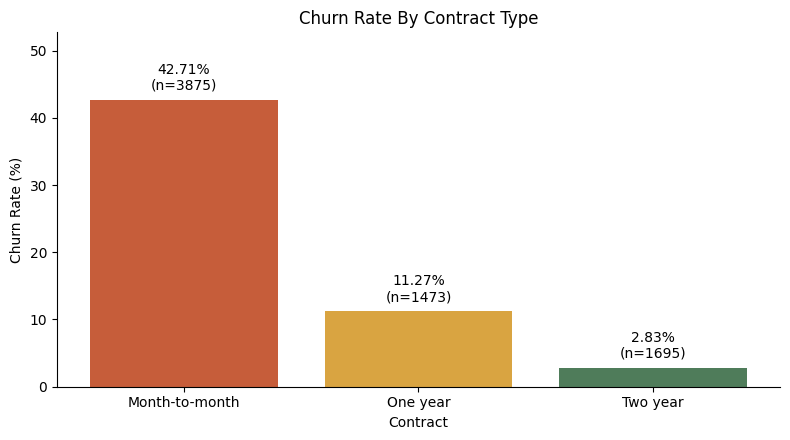

,Contract,customer_count,churn_rate_pct
0,Month-to-month,3875,42.71
1,One year,1473,11.27
2,Two year,1695,2.83


In [15]:
contract_churn_summary = (
    df.groupby("Contract", dropna=False)["Churn_bin"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "churn_rate", "count": "customer_count"})
)
contract_churn_summary["churn_rate_pct"] = (contract_churn_summary["churn_rate"] * 100).round(2)
contract_order = ["Month-to-month", "One year", "Two year"]
contract_churn_summary["Contract"] = pd.Categorical(contract_churn_summary["Contract"], categories=contract_order, ordered=True)
contract_churn_summary = contract_churn_summary.sort_values("Contract")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(contract_churn_summary["Contract"].astype(str), contract_churn_summary["churn_rate_pct"], color=["#c65d3a", "#d9a441", "#4f7c5a"])
ax.set_title("Churn Rate By Contract Type")
ax.set_xlabel("Contract")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, contract_churn_summary["churn_rate_pct"].max() + 10)
ax.spines[["top", "right"]].set_visible(False)

for bar, churn_rate, customer_count in zip(bars, contract_churn_summary["churn_rate_pct"], contract_churn_summary["customer_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{churn_rate:.2f}%\n(n={int(customer_count)})",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

contract_churn_summary[["Contract", "customer_count", "churn_rate_pct"]]


## Feature Engineering Summary

Feature engineering focused on making churn-related business behavior easier to detect and easier to model. The most useful additions were contract encodings, customer-behavior flags, spend transformations, grouped categorical fields, and interaction-style summaries that captured retention profiles.


In [16]:
feature_engineering_summary_df = pd.DataFrame(
    {
        "feature_family": [
            "Contract and lifecycle features",
            "Customer-behavior flags",
            "Spend transformations",
            "Grouped categorical features",
            "Interaction and profile features",
        ],
        "examples": [
            "tenure_band, Contract_ordinal, is_month_to_month, is_new_customer",
            "has_support_services, is_auto_payment, service_count",
            "TotalCharges_log, avg_monthly_spend, tenure_x_MonthlyCharges",
            "payment_method_group, internet_service_group",
            "contract_payment_profile, internet_techsupport_profile, internet_onlinesecurity_profile",
        ],
        "purpose": [
            "Capture churn-relevant timing and commitment effects more explicitly.",
            "Convert service and billing behavior into compact retention signals.",
            "Reduce skew and express spend-related lifecycle behavior more clearly.",
            "Improve interpretability and limit fragmentation from raw category values.",
            "Expose high-risk combinations that are harder to see in single variables alone.",
        ],
    }
)

feature_engineering_summary_df


,feature_family,examples,purpose
0,Contract and lifecycle features,"tenure_band, Contract_ordinal, is_month_to_month, is_new_customer",Capture churn-relevant timing and commitment effects more explicitly.
1,Customer-behavior flags,"has_support_services, is_auto_payment, service_count",Convert service and billing behavior into compact retention signals.
2,Spend transformations,"TotalCharges_log, avg_monthly_spend, tenure_x_MonthlyCharges",Reduce skew and express spend-related lifecycle behavior more clearly.
3,Grouped categorical features,"payment_method_group, internet_service_group",Improve interpretability and limit fragmentation from raw category values.
4,Interaction and profile features,"contract_payment_profile, internet_techsupport_profile, internet_onlinesecurity_profile",Expose high-risk combinations that are harder to see in single variables alone.


Customer-behavior flags and contract encodings were the most consistently useful engineered groups because they aligned directly with churn risk while staying interpretable. Interaction and profile features added strong business context, but they also introduced the highest redundancy risk and should be filtered more carefully during model building.


## Feature Selection Summary

Feature selection narrowed the engineered space into a more defensible modeling shortlist. The goal was not to maximize the number of kept variables, but to separate strong, stable signal from redundancy and low-information noise.


In [17]:
feature_selection_summary_df = pd.DataFrame(
    {
        "metric": [
            "Kept features",
            "Review features",
            "Dropped features",
            "Representative top keep features",
        ],
        "value": [
            feature_selection_snapshot["kept_feature_count"],
            feature_selection_snapshot["review_feature_count"],
            feature_selection_snapshot["dropped_feature_count"],
            ", ".join(feature_selection_snapshot["top_keep_features"][:12]),
        ],
    }
)

feature_selection_summary_df


,metric,value
0,Kept features,39
1,Review features,27
2,Dropped features,20
3,Representative top keep features,"Contract_ordinal, internet_service_group_fiber, InternetService_Fiber optic, TotalCharges_log, StreamingTV_No, MultipleLines_No, OnlineSecurity_No, internet_onlinesecurity_profile_Fiber optic__No, Contract_Two year, TechSupport_No, internet_techsupport_profile_Fiber optic__No, tenure_x_MonthlyCharges"


The strongest feature families moving toward modeling are contract commitment, customer lifecycle, spend and billing behavior, and support-service adoption. Redundant encodings still need model-type-specific decisions, especially around the contract trio (`Contract`, `Contract_ordinal`, `is_month_to_month`) and highly overlapping spend variables such as `TotalCharges`, `TotalCharges_log`, and `tenure_x_MonthlyCharges`.


## Risks And Limitations

EDA findings are highly useful, but they should be interpreted with the right boundaries. The analysis identifies strong associations in the available dataset, not guaranteed causal relationships.


In [18]:
risks_limitations_df = pd.DataFrame(
    {
        "risk_or_limitation": [
            "Association is not causation",
            "Feature redundancy",
            "Class imbalance",
            "Leakage risk",
            "Dataset scope",
        ],
        "implication": [
            "Observed churn patterns are predictive signals, not proof of business causality.",
            "Several engineered and original features act as proxies for the same lifecycle or contract signal.",
            "The 26.54% churn rate can distort accuracy-focused evaluation if not handled carefully.",
            "Preprocessing, scaling, and encoding must happen inside training pipelines rather than on the full dataset.",
            "Insights reflect this dataset only and may not generalize perfectly to other customer populations or time periods.",
        ],
    }
)

risks_limitations_df


,risk_or_limitation,implication
0,Association is not causation,"Observed churn patterns are predictive signals, not proof of business causality."
1,Feature redundancy,Several engineered and original features act as proxies for the same lifecycle or contract signal.
2,Class imbalance,The 26.54% churn rate can distort accuracy-focused evaluation if not handled carefully.
3,Leakage risk,"Preprocessing, scaling, and encoding must happen inside training pipelines rather than on the full dataset."
4,Dataset scope,Insights reflect this dataset only and may not generalize perfectly to other customer populations or time periods.


## Modeling Recommendations

The next phase should translate the EDA work into a leakage-safe modeling pipeline with both interpretable baselines and stronger non-linear comparisons.


## Modeling Handoff Split

The EDA phase should close with the same leakage-safe split that the modeling notebook will inherit. This makes the handoff concrete and confirms the dataset is ready for supervised learning workflows.


In [19]:
X = df[feature_columns].copy()
y = df["Churn_bin"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_test_summary_df = pd.DataFrame(
    {
        "split_component": ["X_train", "X_test", "y_train", "y_test"],
        "shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape],
    }
)

train_test_summary_df


,split_component,shape
0,X_train,"(5634, 40)"
1,X_test,"(1409, 40)"
2,y_train,"(5634,)"
3,y_test,"(1409,)"


In [20]:
modeling_recommendations_df = pd.DataFrame(
    {
        "area": [
            "Data split",
            "Baseline model",
            "Advanced models",
            "Preprocessing",
            "Scaling",
            "Categorical encoding",
            "Evaluation metrics",
            "Threshold tuning",
        ],
        "recommendation": [
            f"Use stratified train/test splitting with TEST_SIZE={TEST_SIZE} and consider stratified cross-validation for model comparison.",
            "Start with Logistic Regression as the most interpretable baseline.",
            "Compare against Random Forest and XGBoost or LightGBM if available.",
            "Perform transformations inside a sklearn pipeline to avoid leakage.",
            "Scale only for linear or distance-based models, not by default for tree ensembles.",
            "Use one-hot encoding for nominal variables and resolve redundant alternate encodings before final training.",
            "Prioritize ROC-AUC, PR-AUC, F1, recall, precision, and confusion-matrix review over raw accuracy.",
            "Tune the classification threshold if the business wants stronger churn recall rather than default probability cutoffs.",
        ],
    }
)

modeling_recommendations_df


,area,recommendation
0,Data split,Use stratified train/test splitting with TEST_SIZE=0.2 and consider stratified cross-validation for model comparison.
1,Baseline model,Start with Logistic Regression as the most interpretable baseline.
2,Advanced models,Compare against Random Forest and XGBoost or LightGBM if available.
3,Preprocessing,Perform transformations inside a sklearn pipeline to avoid leakage.
4,Scaling,"Scale only for linear or distance-based models, not by default for tree ensembles."
5,Categorical encoding,Use one-hot encoding for nominal variables and resolve redundant alternate encodings before final training.
6,Evaluation metrics,"Prioritize ROC-AUC, PR-AUC, F1, recall, precision, and confusion-matrix review over raw accuracy."
7,Threshold tuning,Tune the classification threshold if the business wants stronger churn recall rather than default probability cutoffs.


## Business Recommendations

The analysis supports targeted retention action rather than broad untargeted campaigns. The clearest opportunities sit in month-to-month, early-tenure, weak-support, and higher-friction payment segments.


In [21]:
business_recommendations_df = pd.DataFrame(
    {
        "recommendation": [
            "Prioritize month-to-month customers for retention offers",
            "Intervene earlier in the customer lifecycle",
            "Review electronic-check customer experience",
            "Promote support and security service bundles",
            "Use segment-based retention campaigns",
        ],
        "justification": [
            f"The highest-risk observed segment churns at {top_risk_segment['churn_rate_pct']:.2f}% across {int(top_risk_segment['segment_count'])} customers.",
            f"New month-to-month customers without support services churn at {new_customer_risk['churn_rate_pct']:.2f}% across {int(new_customer_risk['segment_count'])} customers.",
            "Electronic-check groups repeatedly appear among the highest-risk payment profiles.",
            "Low-support groups consistently show weaker retention and lower customer stickiness.",
            "High-risk contract, payment, and support combinations are more actionable than broad customer averages.",
        ],
    }
)

business_recommendations_df


,recommendation,justification
0,Prioritize month-to-month customers for retention offers,The highest-risk observed segment churns at 61.93% across 985 customers.
1,Intervene earlier in the customer lifecycle,New month-to-month customers without support services churn at 53.85% across 1365 customers.
2,Review electronic-check customer experience,Electronic-check groups repeatedly appear among the highest-risk payment profiles.
3,Promote support and security service bundles,Low-support groups consistently show weaker retention and lower customer stickiness.
4,Use segment-based retention campaigns,"High-risk contract, payment, and support combinations are more actionable than broad customer averages."


## Final Conclusion

The clearest analytical and business takeaway is that month-to-month customers paying by electronic check without support services form the most exposed segment in the dataset, with a churn rate of 61.93% across 985 customers. At the other end of the spectrum, two-year auto-payment customers without support services churn at only 1.03% across 390 customers, making contract commitment and billing behavior the strongest practical signals for both modeling and intervention.

The dataset is now ready for baseline and advanced churn modeling using leakage-safe preprocessing, stratified validation, and business-aware evaluation metrics. The next stage should preserve this segment-level signal while testing models that can separate the highest-risk customers early enough to support targeted retention action.
